In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from sklearn.model_selection import train_test_split

In [33]:
def load_data(image_dir, mask_dir):
    images = []
    masks = []

    for img_name in sorted(os.listdir(image_dir)):
        # Read the image
        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is not None:
            img = cv2.resize(img, (256, 256))  # Resize to 256x256

            # Construct corresponding mask path using the same name
            base, _ = os.path.splitext(img_name)
            mask_path = os.path.join(mask_dir, base + ".png")

            # Check if the mask file exists and read it
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    mask = cv2.resize(mask, (256, 256))
                    mask = mask / 255.0  # Normalize mask

                    # Only append when both image and mask are valid
                    images.append(img)
                    masks.append(mask)
                else:
                    print(f"Error reading mask: {mask_path}. Skipping this mask.")
            else:
                print(f"Warning: Mask file not found for {img_name} at {mask_path}. Skipping this image.")
        else:
            print(f"Error reading image: {img_path}. Skipping this image.")

    # Ensure that images and masks are paired correctly
    return np.array(images), np.array(masks).reshape(-1, 256, 256, 1)

In [34]:
image_path = r"D:/heritage_project/data/cracks/image"
mask_path  = r"D:/heritage_project/data/cracks/masks"


In [35]:
images, masks = load_data(image_path, mask_path)
print(images.shape, masks.shape)

(527, 256, 256, 3) (527, 256, 256, 1)


In [36]:
# Check if images and masks are loaded correctly
print(f"Loaded {len(images)} images and {len(masks)} masks")


Loaded 527 images and 527 masks


In [37]:
# Ensure there are enough samples to split
if len(images) == 0 or len(masks) == 0:
    print("No valid image-mask pairs found. Please check your dataset.")
else:
    # Split the data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)


In [44]:
def build_unet_model(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)

    # Decoder
    u1 = UpSampling2D((2, 2))(c4)
    m1 = concatenate([u1, c3])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(m1)

    u2 = UpSampling2D((2, 2))(c5)
    m2 = concatenate([u2, c2])
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(m2)

    u3 = UpSampling2D((2, 2))(c6)
    m3 = concatenate([u3, c1])
    c7 = Conv2D(16, (3, 3), activation='relu', padding='same')(m3)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [45]:
model = build_unet_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 16)      │             448 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 16)      │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 32)      │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 32)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 32, 32, 64)        │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 32, 32, 128)       │          73,856 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 64, 64, 128)       │               0 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64, 64, 192)       │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 64)        │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_1               │ (None, 128, 128, 64)      │               0 │ conv2d_4[0][0]             │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 128, 128, 96)      │               0 │ up_sampling2d_1[0][0],     │
│                               │                           │                 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 128, 128, 32)      │          27,680 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_2               │ (None, 256, 256, 32)      │               

 Total params: 242,721 (948.13 KB)

 Trainable params: 242,721 (948.13 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64
)

# Quick test (optional)
# history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1, batch_size=8)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 130s 19s/step - accuracy: 0.8694 - loss: 0.8808 - val_accuracy: 0.9578 - val_loss: 0.4863
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 152s 21s/step - accuracy: 0.9620 - loss: 0.4448 - val_accuracy: 0.9620 - val_loss: 0.3287
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 144s 20s/step - accuracy: 0.9649 - loss: 0.1980 - val_accuracy: 0.9677 - val_loss: 0.1393
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 129s 19s/step - accuracy: 0.9697 - loss: 0.1066 - val_accuracy: 0.9631 - val_loss: 0.1090
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 97s 13s/step - accuracy: 0.9715 - loss: 0.0853 - val_accuracy: 0.9697 - val_loss: 0.0849
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 96s 13s/step - accuracy: 0.9730 - loss: 0.0734 - val_accuracy: 0.9714 - val_loss: 0.0796
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 68s 10s/step - accuracy: 0.9744 - loss: 0.0687 - val_accuracy: 0.9732 - val_loss: 0.0698
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 71s 10s/step - accuracy: 0.9762 - loss: 0.0620 - val_accuracy: 0.9754 - val_l

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


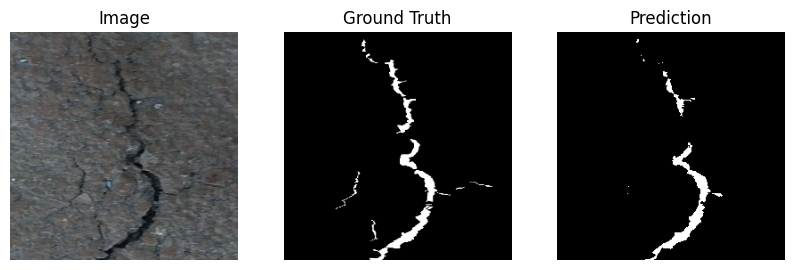

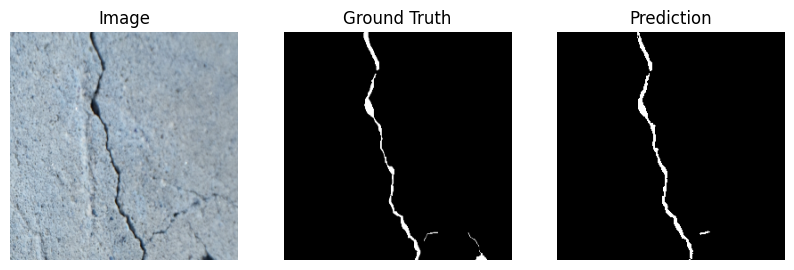

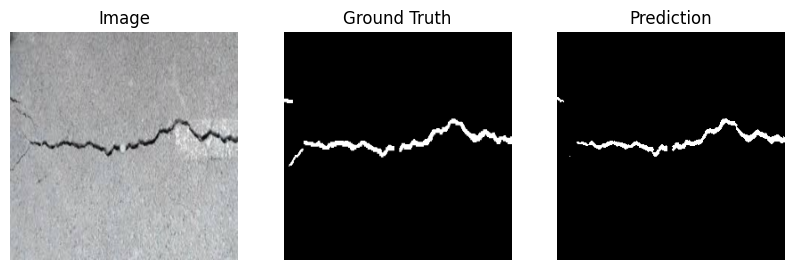

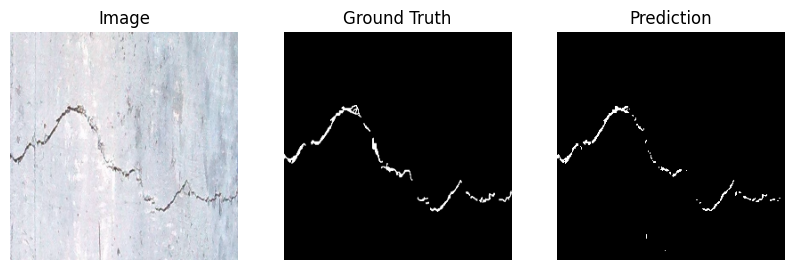

In [49]:

# Get random 4 images from validation set
idxs = np.random.choice(len(X_val), 4, replace=False)
preds = model.predict(X_val[idxs])

for i, idx in enumerate(idxs):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(X_val[idx])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(y_val[idx].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow((preds[i].squeeze() > 0.5).astype("uint8"), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step


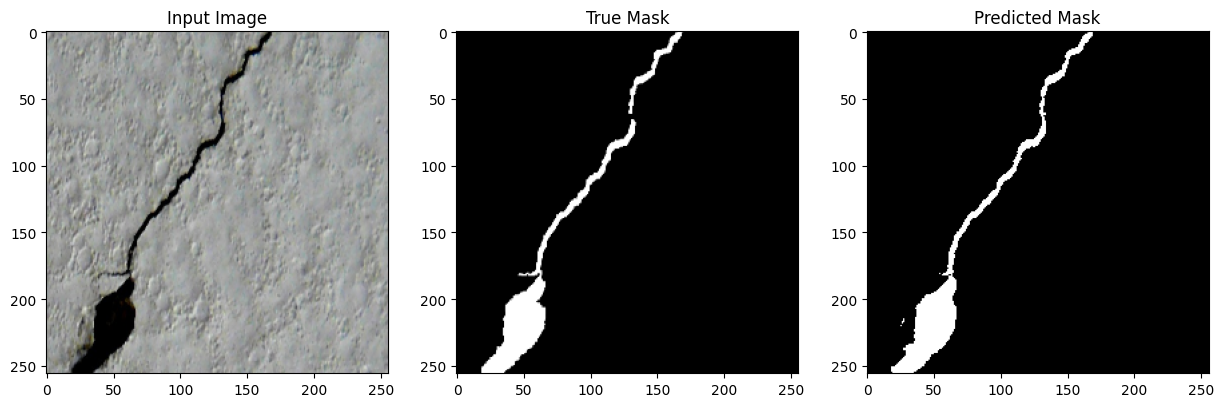

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


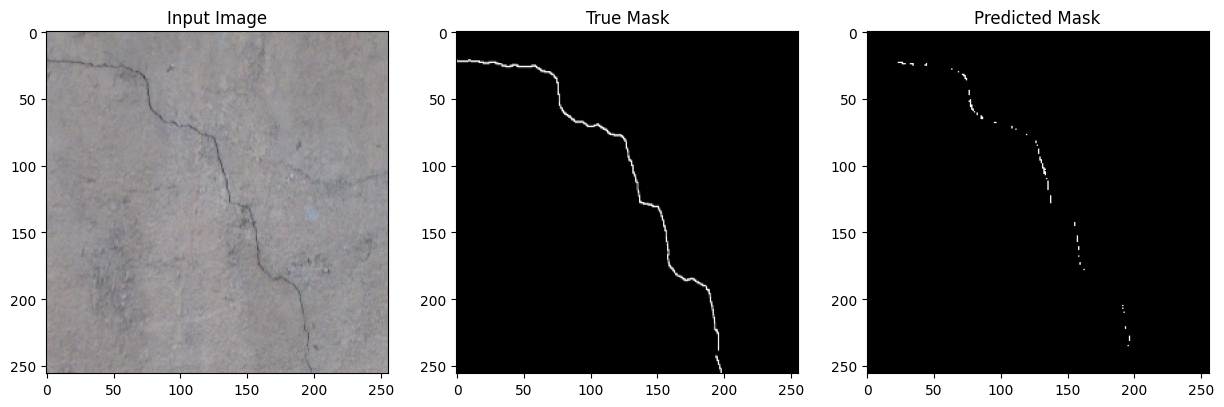

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


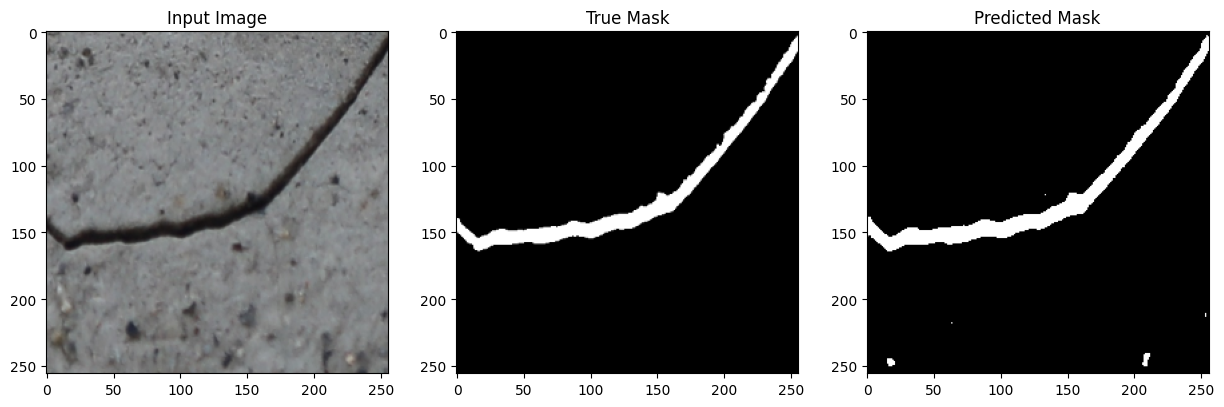

In [50]:
    # Function to visualize predictions
    def visualize_predictions(images, masks, model):
        for i in range(3):  # Display three samples
            img = images[i]
            true_mask = masks[i].squeeze()
            pred_mask = model.predict(img[np.newaxis, ...])[0].squeeze() > 0.5

            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.title("Input Image")
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

            plt.subplot(1, 3, 2)
            plt.title("True Mask")
            plt.imshow(true_mask, cmap='gray')

            plt.subplot(1, 3, 3)
            plt.title("Predicted Mask")
            plt.imshow(pred_mask, cmap='gray')

            plt.show()

    # Visualize some predictions
    visualize_predictions(X_val, y_val, model)

In [52]:
    model.save('D:/heritage_project/models/test_trained_model.h5')

    print("Model saved successfully.")

Model saved successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


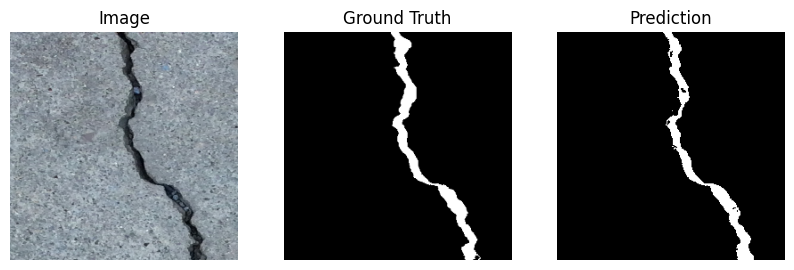

In [55]:
idx = 50
img = X_val[idx]
mask = y_val[idx]

pred = model.predict(img.reshape(1, 256, 256, 3))[0]

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow((pred.squeeze() > 0.5), cmap="gray"); plt.title("Prediction"); plt.axis("off")
plt.show()


In [54]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (421, 256, 256, 3)
Val: (106, 256, 256, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


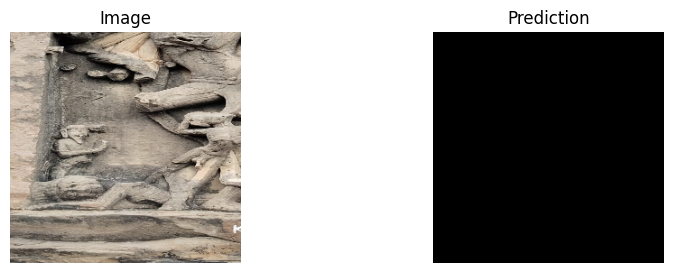

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

file = "C:/Users/Acer/OneDrive/Desktop/pr1.jpg"

img = cv2.imread(file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (256,256)) / 255.0

pred = model.predict(img_resized.reshape(1,256,256,3))[0]

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(img_resized); plt.title("Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow((pred.squeeze() > 0.5), cmap="gray"); plt.title("Prediction"); plt.axis("off")
plt.show()
